# OccPy tutorial notebook for Terrestrial Laser Scanning (TLS) data

This notebook gives a brief overview over TLS occlusion mapping using OccPy.
The data used for this analysis were acquired using a Riegl VZ400i laser scanner at the Rameren forest close to the WSL in Birmensdorf, Switzerland. The forest plot is characterized as a mixed temperate forest and the data was acquired under leaf-on conditions. The data has been heavily filtered to reduce storage needs and reduce processing time. The tutorial data is the same as used for the manuscript currently under revision in RSE and available as pre-print here: (TODO!)
OccPy can be controlled through a JSON settings file, where all necessary settings are defined for a successful execution of OccPy

In [1]:
import json
import os
import shutil
from pathlib import Path

import pooch
from occpy.OccPy import OccPy

RIEGL RDBlib is not available
RIEGL RiVlib is not available
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


First we download the test data an configure paths

In [ ]:
# Download test data once to cache and mirror it into the repository for stable relative paths
repo_root = Path('..', '..').resolve()
data_notebooks = repo_root / 'data_notebooks'
tls_data_dir = data_notebooks / 'TLS_demo'
data_notebooks.mkdir(parents=True, exist_ok=True)

p = pooch.create(
    path=pooch.os_cache('occpy_test_data'),
    base_url='https://zenodo.org/records/17750604/files/',
    registry={'TLS_demo.zip': 'md5:ff15ef6b1b6e655e33c50020089dad56'},
)
p.fetch('TLS_demo.zip', processor=pooch.Unzip(members=['TLS_demo']), progressbar=True)

cache_data_dir = Path(p.path) / 'TLS_demo.zip.unzip' / 'TLS_demo'
if not tls_data_dir.exists():
    shutil.copytree(cache_data_dir, tls_data_dir)

print(f'Notebook data folder: {tls_data_dir}')
config_file = str(repo_root / 'config' / 'settings_TLS_tutorial.JSON')

Repository notebook data folder: /home/wcherlet/repos/occpy_tests/OccPy/data_notebooks/TLS_demo


### Configs

Occpy configurations are saved in JSON files.
 
There are a few minimal requirements for a run:
- laz_in: input laz file or directory containing laz files. If given multiple las files, will assume multi-position TLS. If given single las file, will assume single-position TLS unless is_mobile is set.
- 'plot_dim': grid for occlusion mapping: [minX, minY, minZ, maxX, maxY, maxZ]  
- vox_dim: voxel size - currently this applies to x, y, and z dimension. Non-cubic voxels are on the list of features to be added

Optional arguments:  
- 'is_mobile': whether the acquisition is mobile (MLS/ULS) or static (TLS) (default: False)
- 'single_return': whether the data is single return or multi return data (default: False)
- 'out_dir' : output directory (default: ./output)
- 'verbose': set logging level  (default: False)
- 'debug': set logging level (default: False)
- 'lower_threshold': lower threshold above ground to exclude from occlusion mapping in voxels (default: 0)
- 'points_per_iter': number of points read in from laz file in each iteration (default: 10000000)
- 'delimiter': csv delimiter for scan position file (default: ",")
- 'root_folder': if given, will assume other paths are relative to this root folder and will prepend it to the paths (default: None)
- 'str_idxs_ScanPosID': string indices of where the scan position identifier is written in the laz file name. If not given, will use file name as ID (without extension) (default: None)
- 'output_voxels' : whether to export .ply voxel grids (large files, slow) (default: False)

Additionally, we use the config file to save paths to other files, such as the positions file, DSM and DTM.

In [3]:
# Load config and resolve all relative paths once for downstream plotting/normalization calls
with open(config_file, 'r') as file:
    config = json.load(file)

config

{'root_folder': '../..',
 'laz_in': 'data_notebooks/TLS_demo/LAZ/',
 'out_dir': 'output/TLS',
 'vox_dim': 0.1,
 'lower_threshold': 1,
 'points_per_iter': 1000000,
 'plot_dim': [2676515, 1246063, 545, 2676525, 1246113, 590],
 'output_voxels': False,
 'single_return': False,
 'is_mobile': False,
 'str_idxs_ScanPosID': [7, 10],
 'debug': False,
 'verbose': True,
 'tif_in': {'DTM': 'data_notebooks/TLS_demo/Grids/Ramerenwald_DTM_20250305.tif',
  'DSM': 'data_notebooks/TLS_demo/Grids/Ramerenwald_DSM_20250305.tif'},
 'ScanPos': 'data_notebooks/TLS_demo/ScanPos/ScanPositions.txt'}

### Running OccPy

First step is to create an OccPy object with the config file.

In [11]:
test = OccPy(config_file=config_file)

2026-03-19 11:37:20,116 - INFO - Prepending root folder /home/wcherlet/repos/occpy_tests/OccPy to input and output paths.


INFO: optional arguments: ['out_dir', 'output_voxels', 'verbose', 'debug', 'lower_threshold', 'points_per_iter', 'delimiter', 'root_folder', 'single_return', 'str_idxs_ScanPosID']


Then, define the sensor positions.

In [12]:
test.define_sensor_pos(path2file=config['ScanPos'],             # Path to csv file with scanner positions
                       delimiter=',',                           # Delimiter used in the csv file
                       hdr_scanpos_id='ID',                     # Header for the scan position ID [expected an integer that should be linkable to the laz file - number should be in the laz file name]
                       hdr_x='X',                               # Header for the x coordinate
                       hdr_y='Y',                               # Header for the y coordinate
                       hdr_z='Z',                               # Header for the z coordinate
                       sens_pos_id_offset=0                     # very specific case, where there is an offset between scan position id in the file name and on the ID of the file
                       )

2026-03-19 11:37:22,950 - WARNING - Provided path to sensor position file data_notebooks/TLS_demo/ScanPos/ScanPositions.txt is not absolute. Resolving relative to root folder /home/wcherlet/repos/occpy_tests/OccPy.
2026-03-19 11:37:22,952 - INFO - Defining sensor positions for static acquisition.


Now we can start the raytracing and save the outputs.  
Note: An alternative approach is shown in TLS_notebook_individualLAZ.ipynb. There OccPy is run seperately for each scan, which could be useful for insights into individual scan contribution to the overall occlusion.

In [13]:
import time
tic = time.time()
test.do_raytracing()
toc = time.time()
print(f"Raytracing took {toc - tic:.2f} seconds.")

###############################
##### Processing ScanPos033_sort_filtered.laz...
###############################


2026-03-19 11:37:25,930 - INFO - Do raytracing with stored pulses
2026-03-19 11:37:26,473 - INFO - Time elapsed for raytracing batch: 0.54 seconds


2026-03-19 11:37:27,992 - INFO - Do raytracing with stored pulses
2026-03-19 11:37:28,685 - INFO - Time elapsed for raytracing batch: 0.69 seconds


2026-03-19 11:37:30,229 - INFO - Do raytracing with stored pulses
2026-03-19 11:37:31,497 - INFO - Time elapsed for raytracing batch: 1.27 seconds


2026-03-19 11:37:33,057 - INFO - Do raytracing with stored pulses
2026-03-19 11:37:34,122 - INFO - Time elapsed for raytracing batch: 1.06 seconds


...

 36% [=======             ]========      ]

2026-03-19 11:38:33,354 - INFO - Time elapsed for raytracing incomplete pulses: 4.54 seconds
2026-03-19 11:38:33,383 - INFO - Time elapsed for reading and raytracing entire data: 17.65 seconds
2026-03-19 11:38:33,385 - INFO - Extracting Nhit


#### 16948337 Pulses were traversed of possible 18056952 Pulses
#### 8672978 Returns have been registered by the algorithm 
#### 14374613 Returns were found outside the voxel grid 
#### 6203 Returns were missed during the traversal!
#### 1108615 Pulses did not intersect voxel grid!


2026-03-19 11:38:34,218 - INFO - Elapsed Time: 0.83 seconds
2026-03-19 11:38:34,220 - INFO - Extracting Nocc
2026-03-19 11:38:34,853 - INFO - Elapsed Time: 0.63 seconds
2026-03-19 11:38:34,855 - INFO - Extracting Nmiss
2026-03-19 11:38:35,508 - INFO - Elapsed Time: 0.65 seconds
2026-03-19 11:38:35,510 - INFO - Saving Occlusion Outputs As .npy
2026-03-19 11:38:35,612 - INFO - Elapsed Time: 0.10 seconds
2026-03-19 11:38:35,613 - INFO - Classify Grid
2026-03-19 11:38:35,967 - INFO - Elapsed Time: 0.35348033905029297 seconds


Raytracing took 71.24 seconds.


We can now height normalize the outputs using the provided DTM and DSM file. The DSM file is only to define the upper bounds of the canopy. Function 'normalize_occlusion_output' will also store the normalized voxel grids as npy files in the specified output folder

In [14]:
from occpy.util import normalize_occlusion_output

Nhit_norm, Nmiss_norm, Nocc_norm, Classification_norm, chm = normalize_occlusion_output(input_folder=os.path.join(config["root_folder"], config['out_dir']),
                                                                                        PlotDim=config['plot_dim'],
                                                                                        vox_dim=config['vox_dim'],
                                                                                        dtm_file=os.path.join(config["root_folder"], config['tif_in']['DTM']),
                                                                                        dsm_file=os.path.join(config["root_folder"], config['tif_in']['DSM']),
                                                                                        lower_threshold=config['lower_threshold'],
                                                                                        output_voxels=config['output_voxels'])

# If instead of a binary voxel grid classification, you are intereded in a fraction of occluded pulses per voxel, you can use the following function:
EPS = 1e-6  # small value to avoid division by zero
OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float) + EPS)


Saving normalized output files into directory as .npy...


We can also visualize the results. Note that the amount of occlusion shown here is very high. This is due to the heavy filtering of the input data consisting of only 20% of the original data. The same figure based on the original data can be seen in the paper Kükenbrink et al. (under revision) [Preprint available here: https://doi.org/10.31223/X5N16X]

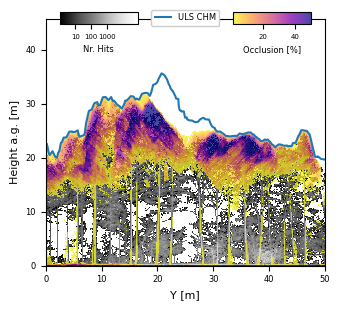

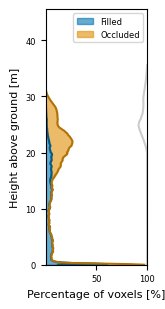

In [17]:
from occpy.visualization import get_Occl_TransectFigure_BinaryOcclusion

# first define figure properties
fig_prop = dict(fig_size=(3.5, 3.2),        # figure size in inches
                label_size=8,               # label size in pts. for e.g. axis labels
                label_size_ticks=6,         # label size in pts. for e.g. axis ticks
                label_size_tiny=5,          # label size in pts. for e.g. ticks in colorbar
                out_format='png',)          # output format of the figure, can be 'png', 'pdf', 'svg', etc.

%matplotlib inline
get_Occl_TransectFigure_BinaryOcclusion(Nhit_norm, Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'],
                                        out_dir=os.path.join(config["root_folder"], config['out_dir']), axis=0, start_ind=0, end_ind=100, chm=chm, vertBuffer=10, fig_prop=fig_prop, show_plots=True)

# Also get a profile figure of the transect
from occpy.visualization import get_Occlusion_ProfileFigure

# define other figure properties for the smaller figure
fig_prop = dict(fig_size=(1.75, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png', )
get_Occlusion_ProfileFigure(Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'], out_dir=os.path.join(config["root_folder"], config['out_dir']), low_thresh=0, vertBuffer=10, max_percentage=100, fig_prop=fig_prop, show_plots=True)

The missing part in the middle of the transect close to top of canopy is unobserved volume. This is caused by the few selected Scan stations for the purpose of this tutorial, where all scan stations were setup as vertical scans with the Riegl scanner (no tilted scans). This can lead to unobserved volumes in the canopy. Please see Figure 4 in Kükenbrink et al. (under revision) [Preprint available here: https://doi.org/10.31223/X5N16X] to see how the occlusion map looks like when all scan positions were used.